# Logistic regression, step by step

**Logistic regression** answers **yes or no** questions. Despite its name, it is used for **classification**, not for predicting a number.

Our question: **will a student pass the exam, based on how many hours they revised?**

We will:

1. Look at the data
2. See why a straight line does not work
3. Meet the S-shaped curve that fixes it
4. Train a logistic regression model and read what it learned
5. Work out a prediction by hand
6. Turn probabilities into yes or no answers

Run each cell in order with **Shift + Enter**.

## Key words

| Word | Meaning |
|---|---|
| **Probability** | A chance between 0 (never) and 1 (certain). 0.75 means a 75% chance |
| **Score (z)** | A number worked out from the features, just like in linear regression |
| **Sigmoid** | The S-shaped "squash" that turns any score into a probability |
| **Threshold** | The cut-off for saying yes, usually 0.5 (50%) |

## Step 1: Setting up

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression

import warnings
warnings.filterwarnings("ignore")   # hide technical warnings so the output is easier to read

## Step 2: The data

We make up 40 students. For each one we know how many **hours** they revised and whether they **passed** (1) or **failed** (0). Students who revise more are more likely to pass, but it is not guaranteed.

In [2]:
rng = np.random.default_rng(4)      # fixed seed, so everyone gets the same students

hours = np.round(rng.uniform(0, 10, 40), 1)
chance = 1 / (1 + np.exp(-1.2 * (hours - 5)))           # hidden rule used to make the data
passed = (rng.random(40) < chance).astype(int)

students = pd.DataFrame({"hours": hours, "passed": passed})
students.head(10)

,hours,passed
0,9.4,1
1,5.1,0
2,9.8,1
3,0.8,0
4,6.1,1
5,3.8,1
6,8.0,1
7,1.7,0
8,8.7,1
9,5.4,1


In [3]:
print("Students who passed:", passed.sum(), "out of", len(passed))

Students who passed: 26 out of 40


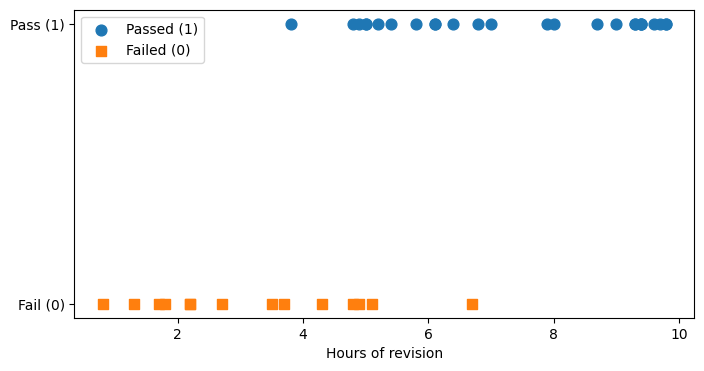

In [4]:
plt.figure(figsize=(8, 4))
plt.scatter(hours[passed == 1], passed[passed == 1], color="tab:blue", s=60, label="Passed (1)")
plt.scatter(hours[passed == 0], passed[passed == 0], color="tab:orange", marker="s", s=60, label="Failed (0)")
plt.xlabel("Hours of revision")
plt.yticks([0, 1], ["Fail (0)", "Pass (1)"])
plt.legend()
plt.show()

Every student sits at either 0 or 1. Most students who failed revised only a little, and most who passed revised a lot, but there is some overlap in the middle.

## Step 3: Why not use a straight line?

Let's try ordinary **linear regression**, which we used earlier for predicting numbers, and see what it says.

In [5]:
X = hours.reshape(-1, 1)          # scikit-learn wants the features as a column

line = LinearRegression()
line.fit(X, passed)

print("Straight line at 0 hours: ", round(line.predict([[0]])[0], 2))
print("Straight line at 10 hours:", round(line.predict([[10]])[0], 2))

Straight line at 0 hours:  -0.11
Straight line at 10 hours: 1.17


If we read these as chances of passing, the line says **−11%** at 0 hours and **117%** at 10 hours. That is impossible: a chance must be between 0% and 100%.

A straight line keeps going forever. We need something that **bends** and stays between 0 and 1.

## Step 4: The S-shaped squash (sigmoid)

The **sigmoid** function takes **any number** and squashes it into a value between 0 and 1:

> p = 1 / (1 + e<sup>−z</sup>)

You do not need to calculate it by hand. Just look at what it does.

In [6]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

for z in [-6, -4, -2, 0, 2, 4, 6]:
    print(f"z = {z:3d}   ->   p = {sigmoid(z):.3f}")

z =  -6   ->   p = 0.002
z =  -4   ->   p = 0.018
z =  -2   ->   p = 0.119
z =   0   ->   p = 0.500
z =   2   ->   p = 0.881
z =   4   ->   p = 0.982
z =   6   ->   p = 0.998


- A score of **0** gives exactly **0.5**: a 50/50 chance.
- Big positive scores get close to **1**, but never go past it.
- Big negative scores get close to **0**, but never go below it.

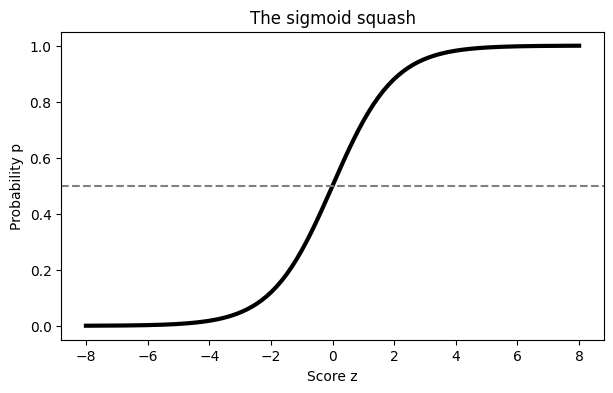

In [7]:
z_values = np.linspace(-8, 8, 200)

plt.figure(figsize=(7, 4))
plt.plot(z_values, sigmoid(z_values), color="black", linewidth=3)
plt.axhline(0.5, color="grey", linestyle="--")
plt.xlabel("Score z")
plt.ylabel("Probability p")
plt.title("The sigmoid squash")
plt.show()

## Step 5: Train a logistic regression model

Logistic regression works in two steps:

1. Work out a **score**: z = m × hours + c (exactly like a straight line)
2. **Squash** the score into a probability with the sigmoid

Training finds the best values for **m** and **c**. (The setting `C=np.inf` switches off an extra feature called regularisation, so the numbers match the simple formula.)

In [8]:
model = LogisticRegression(C=np.inf)
model.fit(X, passed)

m = model.coef_[0][0]
c = model.intercept_[0]
print(f"m = {m:.2f}")
print(f"c = {c:.2f}")

m = 1.31
c = -6.11


So the model's score is: **z = 1.31 × hours − 6.11**

- **m is positive**, so more hours means a higher score, and a higher chance of passing.
- If m were negative, more hours would mean a *lower* chance.

## Step 6: A prediction by hand

Let's work out the chance of passing for a student who revised **5 hours**.

**Step 1, the score:** z = 1.31 × 5 − 6.11 = 6.55 − 6.11 = **0.44**

**Step 2, the squash:** p = sigmoid(0.44) ≈ **0.61**, a 61% chance of passing.

Now let's check with code. (The code uses the full, unrounded values of m and c, so its score may differ very slightly from 0.44.)

In [9]:
h = 5.0
z = m * h + c
p = sigmoid(z)

print(f"Score z:            {z:.2f}")
print(f"Chance by hand:     {p:.2f}")
print(f"Chance from model:  {model.predict_proba([[h]])[0][1]:.2f}")

Score z:            0.45
Chance by hand:     0.61
Chance from model:  0.61


`predict_proba` gives two numbers for each student: the chance of **failing** and the chance of **passing**. We take the second one, `[1]`.

Now let's draw the whole S-curve over the data.

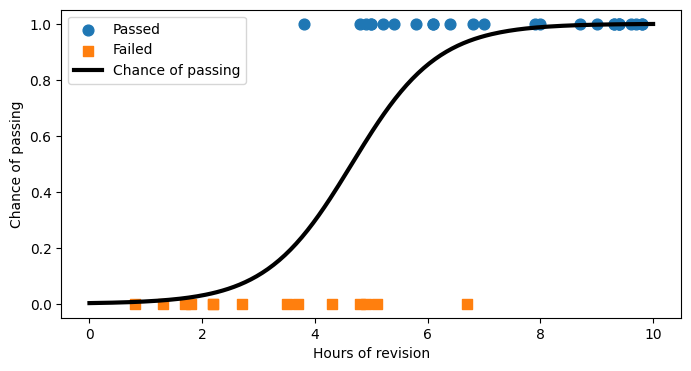

In [10]:
hours_grid = np.linspace(0, 10, 200).reshape(-1, 1)
chance_of_passing = model.predict_proba(hours_grid)[:, 1]

plt.figure(figsize=(8, 4))
plt.scatter(hours[passed == 1], passed[passed == 1], color="tab:blue", s=60, label="Passed")
plt.scatter(hours[passed == 0], passed[passed == 0], color="tab:orange", marker="s", s=60, label="Failed")
plt.plot(hours_grid, chance_of_passing, color="black", linewidth=3, label="Chance of passing")
plt.xlabel("Hours of revision")
plt.ylabel("Chance of passing")
plt.legend()
plt.show()

The curve stays between 0 and 1. It is flat at the ends, where the result is almost certain, and steep in the middle, where students are on the borderline.

## Step 7: From a probability to yes or no

To make a decision we use a **threshold**. The usual rule is:

> If the chance of passing is **0.5 or more**, predict **pass**. Otherwise predict **fail**.

`model.predict` does this for us. Let's see it for 1 to 9 hours.

In [11]:
table = pd.DataFrame({"hours": np.arange(1, 10, dtype=float)})
table["chance of passing"] = model.predict_proba(table[["hours"]].values)[:, 1].round(2)
table["prediction"] = ["pass" if p == 1 else "fail" for p in model.predict(table[["hours"]].values)]
table

,hours,chance of passing,prediction
0,1.0,0.01,fail
1,2.0,0.03,fail
2,3.0,0.10,fail
3,4.0,0.30,fail
4,5.0,0.61,pass
5,6.0,0.85,pass
6,7.0,0.96,pass
7,8.0,0.99,pass
8,9.0,1.00,pass


The switch from fail to pass happens between 4 and 5 hours. The exact point is where the score is 0, so the chance is 50%:

> 1.31 × hours − 6.11 = 0 → hours = 6.11 ÷ 1.31 ≈ **4.66 hours**

In [12]:
boundary = -c / m
print(f"Decision boundary: {boundary:.2f} hours")

Decision boundary: 4.66 hours


## Step 8: How well does it do?

Let's compare the model's predictions with what really happened to all 40 students.

In [13]:
predictions = model.predict(X)
correct = (predictions == passed).sum()

print("Correct predictions:", correct, "out of", len(passed))
print("Accuracy:", round(correct / len(passed), 3))

Correct predictions: 35 out of 40
Accuracy: 0.875


It gets most students right. The ones it gets wrong are mostly near the boundary: students who revised about 4 to 6 hours, where it really could go either way.

(In a real project we would also test the model on students it has never seen, using a train/test split.)

## Summary

| Idea | What it means |
|---|---|
| The problem | A straight line can predict chances below 0% or above 100% |
| The score | z = m × hours + c, just like linear regression |
| The squash | The sigmoid turns any score into a probability from 0 to 1 |
| The decision | Predict yes if the probability is 0.5 or more |
| The boundary | Where the score is 0: here 4.66 hours |

## Things to try

1. Pick a number of hours of your own. Work out the score and chance of passing by hand, then check with code, for example `model.predict_proba([[3.5]])` for 3.5 hours.
2. Change the threshold to **0.7**: count how many of the 40 students would be predicted to pass using `(model.predict_proba(X)[:, 1] >= 0.7).sum()`. Why might a teacher want a higher or lower threshold?
3. In Step 2, change the seed in `default_rng(4)` to another number and run everything again. How much do m, c and the boundary change?

In [14]:
# Your experiments here